# Suggestion Mining in High-Rated Hotel Reviews — Full Pipeline

This notebook runs the complete suggestion mining pipeline end-to-end, from raw data loading through model evaluation and insight generation. It serves as both a reproducible artifact and a practical re-run tool.

**Research question:** Can we automatically identify actionable suggestions in 4-5 star Marina Bay Sands TripAdvisor reviews, and what topics do those suggestions cover?

**Pipeline phases:**
1. Data Loading & Preprocessing
2. Exploratory Data Analysis
3. Annotation Summary
4. Model Development (Regex → TF-IDF+LR → BERT two-stage)
5. Topic Modeling (BERTopic + aspect grouping)
6. Error Analysis

All logic lives in `src/` modules — this notebook is a thin wrapper that calls those functions and displays results.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

# Print environment info
import platform
print(f"Python {platform.python_version()}")
try:
    import torch
    print(f"PyTorch {torch.__version__} | MPS: {torch.backends.mps.is_available()} | CUDA: {torch.cuda.is_available()}")
except ImportError:
    print("PyTorch not installed")
try:
    import transformers
    print(f"Transformers {transformers.__version__}")
except ImportError:
    print("Transformers not installed")

Python 3.13.12
PyTorch 2.10.0 | MPS: True | CUDA: False
Transformers 5.3.0


---
# Phase 1: Data Loading & Preprocessing

Load 10,232 raw TripAdvisor reviews, filter to 4-5 star ratings (8,571 reviews), then segment into individual sentences using spaCy. Sentences are filtered to 4-100 tokens, deduplicated, and non-English text removed via ASCII ratio heuristic.

In [2]:
from src.data_loading import load_and_filter_reviews

df_reviews = load_and_filter_reviews(save=True)
print(f"\nFiltered reviews: {len(df_reviews):,} rows")
print(f"Rating split — 4-star: {(df_reviews['rating'] == 4).sum():,}, 5-star: {(df_reviews['rating'] == 5).sum():,}")
df_reviews.head(3)

Raw dataset: 10232 reviews
After 4-5 star filter + null drop: 8571 reviews
Saved to /Users/c47b07/Documents/UCL/Term_2/Natural_Language_Processing/NLP_Team6/data/processed/mbs_filtered_reviews.csv

Filtered reviews: 8,571 rows
Rating split — 4-star: 2,414, 5-star: 6,157


,review_id,rating,date,review_title,review_text
0,0,5,2022-08-01,Great stay,Whole team was great and service 10/10. Receiv...
1,1,5,2022-07-01,MBS a luxurious destination,"We are a family of 6 ( my 85 yearold father, 7..."
2,2,5,2022-08-01,MBS truly understands their clients!,"Throughout my stay, I felt that this establish..."


In [3]:
from src.preprocessing import preprocess_sentences

df_sents = preprocess_sentences(save=True)
print(f"\nSentences: {len(df_sents):,} rows")
print(f"Token length — min: {df_sents['n_tokens'].min()}, max: {df_sents['n_tokens'].max()}, "
      f"median: {df_sents['n_tokens'].median():.0f}")
print(f"\nSample sentences:")
for _, row in df_sents.sample(5, random_state=42).iterrows():
    print(f"  [{row['n_tokens']:2d} tokens] {row['sentence_text'][:100]}")

Loaded 8571 filtered reviews


Segmenting sentences: 100%|██████████| 8571/8571 [02:33<00:00, 55.92it/s]


Segmented 8571 reviews into 72391 sentences (8.4 avg per review)


Language filtering: 100%|██████████| 72391/72391 [00:00<00:00, 416188.44it/s]

Language filter: removed 1 non-English sentences (threshold: 0.5)
Dedup: removed 1137 duplicate sentences
Length filter (4-100 tokens): removed 1168 sentences
Final: 70085 sentences from 8559 reviews


Saved to /Users/c47b07/Documents/UCL/Term_2/Natural_Language_Processing/NLP_Team6/data/processed/mbs_sentences.csv

Sentences: 70,085 rows
Token length — min: 4, max: 100, median: 15

Sample sentences:
  [10 tokens] I had a great staycation to celebrate my anniversary.
  [27 tokens] "Sky 57   " offers unique cocktails and a fantastic view , day or night , either to Marina Bay or th
  [14 tokens] The hotel has the standard of any 5 star hotel in the world.
  [ 6 tokens] The gym was good too.
  [10 tokens] Can pay deposit and room buy card/cash.


---
# Phase 2: Exploratory Data Analysis

Analyse the MBS dataset statistics and quantify the domain gap between MBS hotel reviews and SemEval-2019 software forum data. This gap motivates the two-stage domain adaptation approach in Phase 4.

In [4]:
from src.config import MBS_FILTERED_REVIEWS, MBS_SENTENCES, FIGURES_DIR
from src.eda import (
    load_semeval_train,
    plot_rating_distribution, plot_review_length_distribution,
    plot_sentence_length_distribution, plot_temporal_distribution,
    count_suggestion_signals, plot_signal_comparison,
    compare_sentence_lengths, compute_vocab_overlap,
    domain_gap_summary_table,
)

df_reviews = pd.read_csv(MBS_FILTERED_REVIEWS)
df_sents = pd.read_csv(MBS_SENTENCES)
df_semeval = load_semeval_train()

print(f"MBS reviews: {len(df_reviews):,}")
print(f"MBS sentences: {len(df_sents):,}")
print(f"SemEval training sentences: {len(df_semeval):,} ({df_semeval['label'].mean():.1%} suggestions)")

MBS reviews: 8,571
MBS sentences: 70,085
SemEval training sentences: 8,500 (24.5% suggestions)


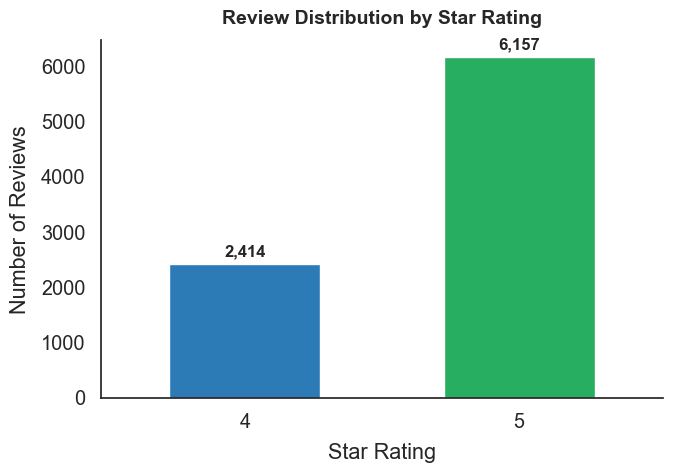

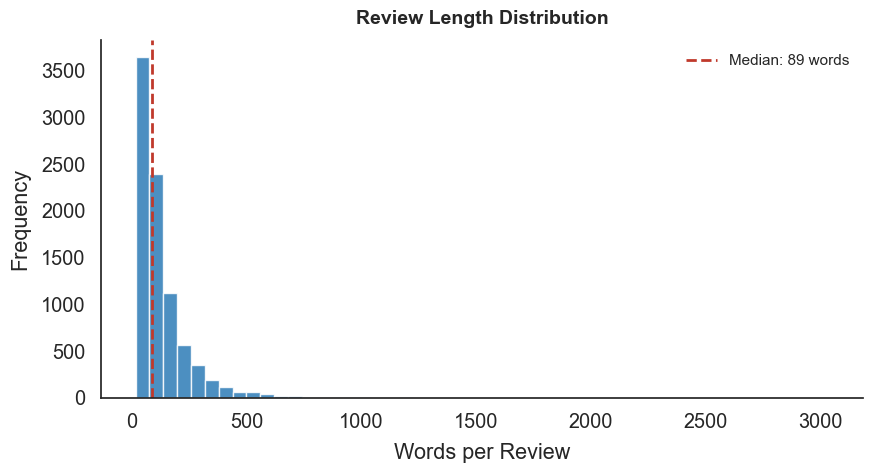

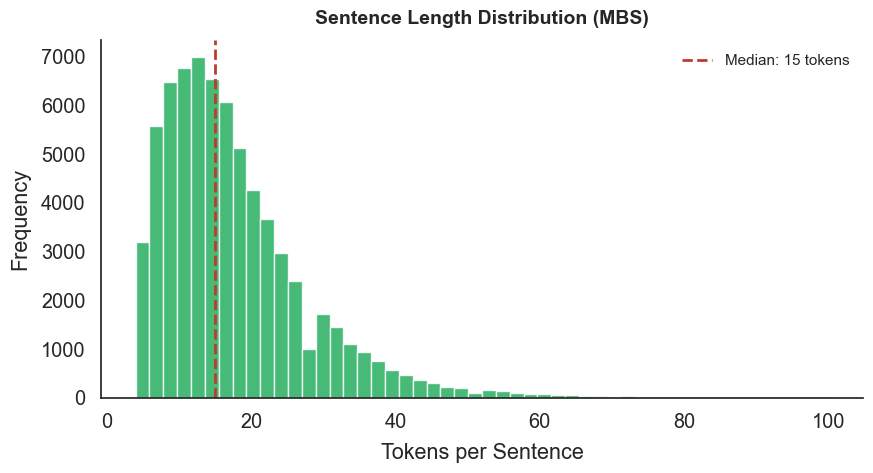

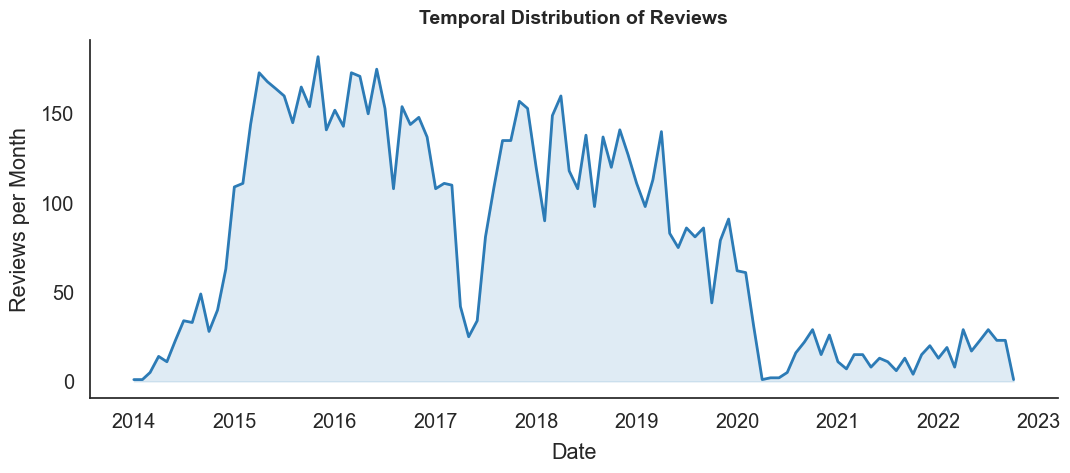

In [5]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# MBS dataset statistics
plot_rating_distribution(df_reviews)
plt.show()

plot_review_length_distribution(df_reviews)
plt.show()

plot_sentence_length_distribution(df_sents)
plt.show()

plot_temporal_distribution(df_reviews)
plt.show()

### Domain Gap: MBS vs. SemEval

The SemEval training data comes from Windows Phone software forums — structurally very different from hotel review language. Low vocabulary overlap (Jaccard ~0.10) motivates domain adaptation.

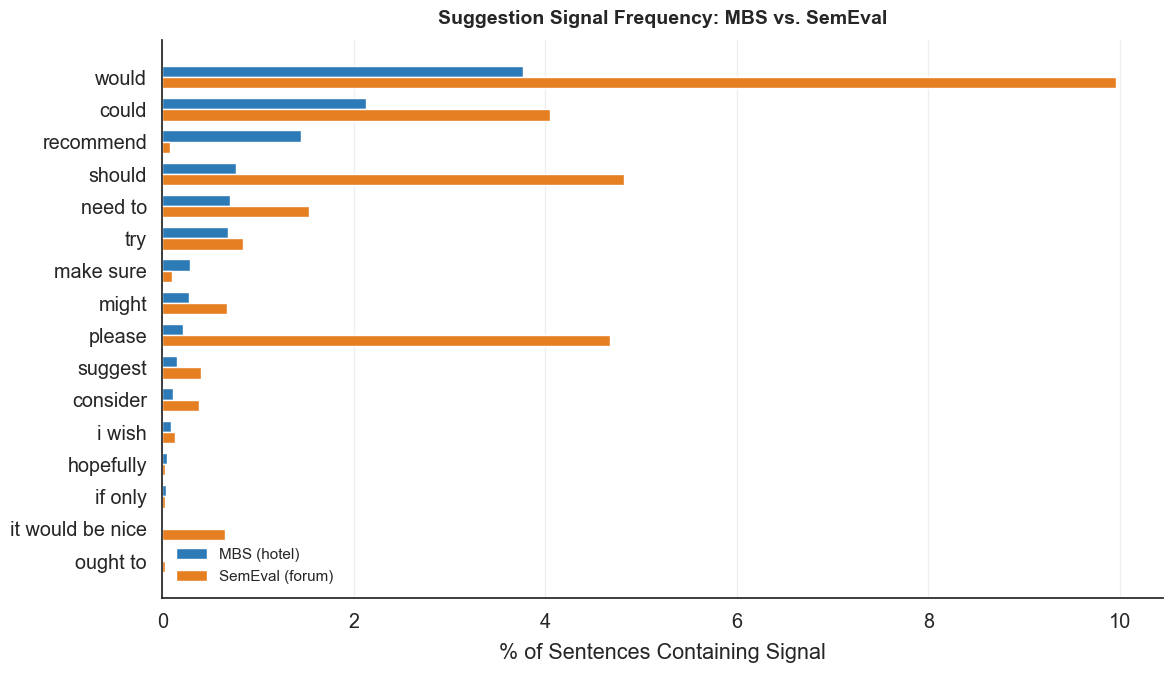

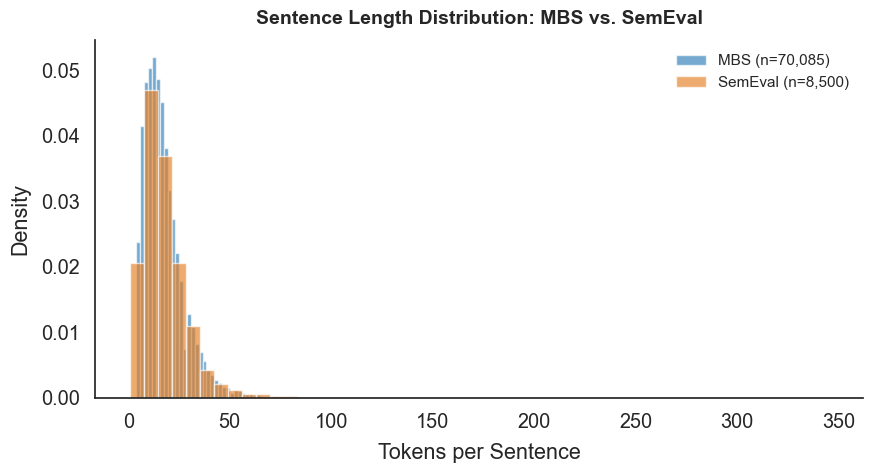

Building SemEval vocab: 100%|██████████| 8500/8500 [00:00<00:00, 616702.72it/s]



Vocabulary Overlap:
  mbs_vocab_size: 36,722
  semeval_vocab_size: 18,347
  overlap_size: 5,175
  jaccard: 0.104
  mbs_coverage: 0.141
  semeval_coverage: 0.282

Domain Gap Summary:


Building SemEval vocab: 100%|██████████| 8500/8500 [00:00<00:00, 631974.62it/s]


,Metric,MBS,SemEval
0,Number of sentences,"70,085","8,500"
1,Median sentence length (words),13,15
2,Mean sentence length (words),15.4,17.8
3,Vocabulary size,"36,722","18,347"
4,Vocabulary overlap (Jaccard),0.104,—
5,Suggestion base rate (%),TBD (after annotation),24.5
6,Domain,Hotel reviews (TripAdvisor),Software forums (Windows Phone)


In [6]:
# Suggestion signal comparison
mbs_signals = count_suggestion_signals(df_sents, text_col="sentence_text")
sem_signals = count_suggestion_signals(df_semeval, text_col="text")
plot_signal_comparison(mbs_signals, sem_signals)
plt.show()

# Sentence length comparison
compare_sentence_lengths(df_sents, df_semeval)
plt.show()

# Vocabulary overlap
vocab = compute_vocab_overlap(df_sents, df_semeval)
print("\nVocabulary Overlap:")
for k, v in vocab.items():
    print(f"  {k}: {v:,.3f}" if isinstance(v, float) else f"  {k}: {v:,}")

# Domain gap summary
print("\nDomain Gap Summary:")
domain_gap_summary_table(df_sents, df_semeval)

---
# Phase 3: Annotation Summary

400 sentences were manually annotated by 4 annotators (Chase, Clara, Leah, Xiayi):
- **Calibration round:** 100 shared sentences labelled independently by all 4 annotators. Fleiss' kappa = 0.379 (fair agreement). Guidelines revised (v1.0 → v1.1) to address disagreements on complaints vs. suggestions. Labels resolved by majority vote (89) + team consensus (11).
- **Split annotation:** 300 additional sentences split into 4 batches of 75, one per annotator.
- **Final dataset:** 400 annotated sentences — 73 suggestions (18.2%), 327 non-suggestions.
- **Train/test split:** Stratified 80/20 (320 train / 80 test).

This cell loads the existing annotations rather than re-running the sampling process.

In [7]:
from src.config import (
    MBS_CALIBRATION_SHEET, MBS_ANNOTATED_FULL,
    MBS_ANNOTATED_TRAIN, MBS_ANNOTATED_TEST,
)

# Calibration round IAA
cal = pd.read_csv(MBS_CALIBRATION_SHEET)
print(f"Calibration: {len(cal)} sentences")
print(f"  Gold labels: {cal['gold_label'].sum()} suggestions, {(cal['gold_label'] == 0).sum()} non-suggestions")

# Vote distribution
print(f"\n  Vote distribution (sum of 4 annotators):")
for v in sorted(cal["vote_sum"].unique()):
    n = (cal["vote_sum"] == v).sum()
    print(f"    vote_sum={v}: {n} sentences {'(unanimous non-sugg)' if v == 0 else '(unanimous sugg)' if v == 4 else '(2v2 tie)' if v == 2 else ''}")

# Per-annotator label rates
print(f"\n  Annotator suggestion rates (calibration):")
for name in ["chase", "clara", "leah", "xiayi"]:
    col = f"label_{name}"
    rate = cal[col].mean()
    print(f"    {name}: {cal[col].sum()}/{len(cal)} ({rate:.1%})")

# Full annotated dataset
df_full = pd.read_csv(MBS_ANNOTATED_FULL)
df_train = pd.read_csv(MBS_ANNOTATED_TRAIN)
df_test = pd.read_csv(MBS_ANNOTATED_TEST)

print(f"\nFull annotated dataset: {len(df_full)} sentences ({df_full['label'].sum()} suggestions, {df_full['label'].mean():.1%})")
print(f"Train: {len(df_train)} sentences ({df_train['label'].mean():.1%} suggestions)")
print(f"Test:  {len(df_test)} sentences ({df_test['label'].mean():.1%} suggestions)")

# Verify no overlap
overlap = set(df_train["sentence_id"]) & set(df_test["sentence_id"])
print(f"\nTrain/test overlap: {len(overlap)} (expected: 0)")

Calibration: 100 sentences
  Gold labels: 17 suggestions, 83 non-suggestions

  Vote distribution (sum of 4 annotators):
    vote_sum=0: 53 sentences (unanimous non-sugg)
    vote_sum=1: 23 sentences 
    vote_sum=2: 11 sentences (2v2 tie)
    vote_sum=3: 6 sentences 
    vote_sum=4: 7 sentences (unanimous sugg)

  Annotator suggestion rates (calibration):
    chase: 10/100 (10.0%)
    clara: 18/100 (18.0%)
    leah: 43/100 (43.0%)
    xiayi: 20/100 (20.0%)

Full annotated dataset: 400 sentences (73 suggestions, 18.2%)
Train: 320 sentences (18.1% suggestions)
Test:  80 sentences (18.8% suggestions)

Train/test overlap: 0 (expected: 0)


---
# Phase 4: Model Development

Three-tier approach with increasing complexity:
1. **Regex baseline** — rule-based pattern matching (modal verbs, imperatives, conditionals)
2. **TF-IDF + Logistic Regression** — learned features trained on SemEval
3. **BERT two-stage** — Stage 1 on SemEval (in-domain), Stage 2 on MBS (domain adaptation)

All models are evaluated on both SemEval test (in-domain) and MBS test (cross-domain). The central finding is that Stage 2 domain adaptation nearly doubles MBS F1 (0.286 → 0.581).

## 4.1 Baselines: Regex + TF-IDF + Logistic Regression

In [8]:
from src.evaluation import (
    compute_metrics, load_semeval_test, load_semeval_train,
    plot_confusion_matrix, print_report,
    build_comparison_table, plot_comparison_chart,
)
from src.baselines import regex_classify, train_tfidf_lr, predict_tfidf_lr

# Load SemEval + MBS test data
df_se_train = load_semeval_train()
df_se_test = load_semeval_test()
df_mbs_test = pd.read_csv(MBS_ANNOTATED_TEST)

y_true_se = df_se_test["label"].tolist()
y_true_mbs = df_mbs_test["label"].tolist()
texts_se = df_se_test["text"].tolist()
texts_mbs = df_mbs_test["sentence_text"].tolist()

print(f"SemEval train: {len(df_se_train):,} | test: {len(df_se_test):,}")
print(f"MBS test: {len(df_mbs_test)} ({df_mbs_test['label'].sum()} suggestions)")

all_results = []

# --- Regex baseline ---
y_pred_regex_se = regex_classify(texts_se)
y_pred_regex_mbs = regex_classify(texts_mbs)

print_report(y_true_se, y_pred_regex_se, "Regex — SemEval Test")
plot_confusion_matrix(y_true_se, y_pred_regex_se, "Regex — SemEval Test",
                      save_path=FIGURES_DIR / "cm_regex_semeval.png")
plt.show()

print_report(y_true_mbs, y_pred_regex_mbs, "Regex — MBS Test")
plot_confusion_matrix(y_true_mbs, y_pred_regex_mbs, "Regex — MBS Test",
                      save_path=FIGURES_DIR / "cm_regex_mbs.png")
plt.show()

all_results.append({"model": "Regex", "dataset": "SemEval", **compute_metrics(y_true_se, y_pred_regex_se)})
all_results.append({"model": "Regex", "dataset": "MBS", **compute_metrics(y_true_mbs, y_pred_regex_mbs)})

# --- TF-IDF + LR ---
vectorizer, lr_model = train_tfidf_lr(df_se_train["text"].tolist(), df_se_train["label"].tolist())
y_pred_lr_se = predict_tfidf_lr(vectorizer, lr_model, texts_se)
y_pred_lr_mbs = predict_tfidf_lr(vectorizer, lr_model, texts_mbs)

print_report(y_true_se, y_pred_lr_se, "TF-IDF + LR — SemEval Test")
plot_confusion_matrix(y_true_se, y_pred_lr_se, "TF-IDF + LR — SemEval Test",
                      save_path=FIGURES_DIR / "cm_tfidf_lr_semeval.png")
plt.show()

print_report(y_true_mbs, y_pred_lr_mbs, "TF-IDF + LR — MBS Test (cross-domain)")
plot_confusion_matrix(y_true_mbs, y_pred_lr_mbs, "TF-IDF + LR — MBS Test",
                      save_path=FIGURES_DIR / "cm_tfidf_lr_mbs.png")
plt.show()

all_results.append({"model": "TF-IDF + LR", "dataset": "SemEval", **compute_metrics(y_true_se, y_pred_lr_se)})
all_results.append({"model": "TF-IDF + LR", "dataset": "MBS", **compute_metrics(y_true_mbs, y_pred_lr_mbs)})

SemEval train: 8,500 | test: 833
MBS test: 80 (15 suggestions)

  Regex — SemEval Test
                precision    recall  f1-score   support

Non-Suggestion     0.9271    0.9370    0.9320       746
    Suggestion     0.4051    0.3678    0.3855        87

      accuracy                         0.8776       833
     macro avg     0.6661    0.6524    0.6588       833
  weighted avg     0.8725    0.8776    0.8749       833

  Saved: /Users/c47b07/Documents/UCL/Term_2/Natural_Language_Processing/NLP_Team6/outputs/figures/cm_regex_semeval.png

  Regex — MBS Test
                precision    recall  f1-score   support

Non-Suggestion     0.8852    0.8308    0.8571        65
    Suggestion     0.4211    0.5333    0.4706        15

      accuracy                         0.7750        80
     macro avg     0.6531    0.6821    0.6639        80
  weighted avg     0.7982    0.7750    0.7847        80

  Saved: /Users/c47b07/Documents/UCL/Term_2/Natural_Language_Processing/NLP_Team6/outputs/figure

## 4.2 BERT Two-Stage Fine-Tuning

**Stage 1:** Fine-tune `bert-base-uncased` on SemEval training data (software forum suggestions).
**Stage 2:** Further fine-tune on MBS annotated training data (domain adaptation).

Both stages auto-skip training if a checkpoint already exists in `outputs/models/`.

In [9]:
from src.bert_model import get_device, train_stage1, train_stage2, predict as bert_predict

device = get_device()

# --- Stage 1: SemEval fine-tuning ---
model_s1, tokenizer_s1, val_results_s1 = train_stage1()

# Evaluate Stage 1 on SemEval test (in-domain)
y_pred_s1_se = bert_predict(model_s1, tokenizer_s1, texts_se, device)
print_report(y_true_se, y_pred_s1_se, "BERT Stage 1 — SemEval Test")
plot_confusion_matrix(y_true_se, y_pred_s1_se, "BERT Stage 1 — SemEval Test",
                      save_path=FIGURES_DIR / "cm_bert_s1_semeval.png")
plt.show()

# Evaluate Stage 1 on MBS test (cross-domain)
y_pred_s1_mbs = bert_predict(model_s1, tokenizer_s1, texts_mbs, device)
print_report(y_true_mbs, y_pred_s1_mbs, "BERT Stage 1 — MBS Test (cross-domain)")
plot_confusion_matrix(y_true_mbs, y_pred_s1_mbs, "BERT Stage 1 — MBS Test",
                      save_path=FIGURES_DIR / "cm_bert_s1_mbs.png")
plt.show()

all_results.append({"model": "BERT (SemEval)", "dataset": "SemEval", **compute_metrics(y_true_se, y_pred_s1_se)})
all_results.append({"model": "BERT (SemEval)", "dataset": "MBS", **compute_metrics(y_true_mbs, y_pred_s1_mbs)})

  Device: Apple Silicon MPS

  Stage-1 checkpoint found at /Users/c47b07/Documents/UCL/Term_2/Natural_Language_Processing/NLP_Team6/outputs/models/bert_stage1 — loading instead of re-training.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Predicting: 100%|██████████| 27/27 [00:06<00:00,  4.01it/s]



  BERT Stage 1 — SemEval Test
                precision    recall  f1-score   support

Non-Suggestion     0.9804    0.9410    0.9603       746
    Suggestion     0.6239    0.8391    0.7157        87

      accuracy                         0.9304       833
     macro avg     0.8022    0.8900    0.8380       833
  weighted avg     0.9432    0.9304    0.9348       833

  Saved: /Users/c47b07/Documents/UCL/Term_2/Natural_Language_Processing/NLP_Team6/outputs/figures/cm_bert_s1_semeval.png


Predicting: 100%|██████████| 3/3 [00:00<00:00,  4.57it/s]



  BERT Stage 1 — MBS Test (cross-domain)
                precision    recall  f1-score   support

Non-Suggestion     0.8378    0.9538    0.8921        65
    Suggestion     0.5000    0.2000    0.2857        15

      accuracy                         0.8125        80
     macro avg     0.6689    0.5769    0.5889        80
  weighted avg     0.7745    0.8125    0.7784        80

  Saved: /Users/c47b07/Documents/UCL/Term_2/Natural_Language_Processing/NLP_Team6/outputs/figures/cm_bert_s1_mbs.png


In [10]:
# --- Stage 2: MBS domain adaptation ---
model_s2, tokenizer_s2, val_results_s2 = train_stage2()

# Evaluate Stage 2 on MBS test
y_pred_s2_mbs = bert_predict(model_s2, tokenizer_s2, texts_mbs, device)
print_report(y_true_mbs, y_pred_s2_mbs, "BERT Stage 2 — MBS Test")
plot_confusion_matrix(y_true_mbs, y_pred_s2_mbs, "BERT Stage 2 — MBS Test",
                      save_path=FIGURES_DIR / "cm_bert_s2_mbs.png")
plt.show()

all_results.append({"model": "BERT (SemEval+MBS)", "dataset": "MBS", **compute_metrics(y_true_mbs, y_pred_s2_mbs)})


  Stage-2 checkpoint found at /Users/c47b07/Documents/UCL/Term_2/Natural_Language_Processing/NLP_Team6/outputs/models/bert_stage2 — loading instead of re-training.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Predicting: 100%|██████████| 3/3 [00:00<00:00,  4.09it/s]


  BERT Stage 2 — MBS Test
                precision    recall  f1-score   support

Non-Suggestion     0.9062    0.8923    0.8992        65
    Suggestion     0.5625    0.6000    0.5806        15

      accuracy                         0.8375        80
     macro avg     0.7344    0.7462    0.7399        80
  weighted avg     0.8418    0.8375    0.8395        80

  Saved: /Users/c47b07/Documents/UCL/Term_2/Natural_Language_Processing/NLP_Team6/outputs/figures/cm_bert_s2_mbs.png


## 4.3 Full Model Comparison

In [11]:
table = build_comparison_table(all_results)
print("Full Model Comparison:\n")
print(table.to_string(index=False))

plot_comparison_chart(table, metric="f1_1", save_path=FIGURES_DIR / "model_comparison.png")
plt.show()

Full Model Comparison:

             model dataset   f1_1  precision_1  recall_1     f1  precision  recall  accuracy
             Regex SemEval 0.3855       0.4051    0.3678 0.6588     0.6661  0.6524    0.8776
             Regex     MBS 0.4706       0.4211    0.5333 0.6639     0.6531  0.6821    0.7750
       TF-IDF + LR SemEval 0.5956       0.4855    0.7701 0.7662     0.7284  0.8375    0.8908
       TF-IDF + LR     MBS 0.1905       0.3333    0.1333 0.5341     0.5788  0.5359    0.7875
    BERT (SemEval) SemEval 0.7157       0.6239    0.8391 0.8380     0.8022  0.8900    0.9304
    BERT (SemEval)     MBS 0.2857       0.5000    0.2000 0.5889     0.6689  0.5769    0.8125
BERT (SemEval+MBS)     MBS 0.5806       0.5625    0.6000 0.7399     0.7344  0.7462    0.8375
  Saved: /Users/c47b07/Documents/UCL/Term_2/Natural_Language_Processing/NLP_Team6/outputs/figures/model_comparison.png


## 4.4 Full-Dataset Prediction

Run the best model (BERT Stage 2) on all 70,085 MBS sentences to extract predicted suggestions for Phase 5 topic modeling.

In [12]:
from src.config import MBS_PREDICTIONS, PROCESSED_DATA_DIR

df_sents = pd.read_csv(MBS_SENTENCES)
print(f"Full MBS dataset: {len(df_sents):,} sentences")

# Use Stage 2 (best model)
best_model, best_tokenizer, best_name = model_s2, tokenizer_s2, "BERT Stage 2"
print(f"Using: {best_name}")

all_preds = bert_predict(best_model, best_tokenizer, df_sents["sentence_text"].tolist(), device)
df_sents["predicted_label"] = all_preds
n_sugg = sum(all_preds)
print(f"Predicted suggestions: {n_sugg:,} / {len(all_preds):,} ({n_sugg/len(all_preds):.1%})")

df_sents.to_csv(MBS_PREDICTIONS, index=False)
print(f"Saved: {MBS_PREDICTIONS}")

Full MBS dataset: 70,085 sentences
Using: BERT Stage 2


Predicting: 100%|██████████| 2191/2191 [09:30<00:00,  3.84it/s]

Predicted suggestions: 4,179 / 70,085 (6.0%)
Saved: /Users/c47b07/Documents/UCL/Term_2/Natural_Language_Processing/NLP_Team6/data/processed/mbs_predictions.csv


---
# Phase 5: Topic Modeling

Cluster the extracted suggestions using BERTopic (sentence embeddings + UMAP + HDBSCAN) to identify recurring themes. Supplement with keyword-based aspect grouping into hotel categories (room, food, service, etc.).

In [13]:
from src.topic_modeling import (
    load_predicted_suggestions, run_bertopic, get_topic_summary,
    plot_topic_barchart, plot_topic_wordclouds,
    aspect_grouping, get_aspect_summary, plot_aspect_distribution,
)

df_sugg = load_predicted_suggestions()
texts_sugg = df_sugg["sentence_text"].tolist()

print(f"\nSample suggestions:")
for t in texts_sugg[:5]:
    print(f"  - \"{t[:120]}\"")

# BERTopic clustering
topic_model, topics, probs = run_bertopic(texts_sugg, min_topic_size=5)

  Loaded 4179 predicted suggestions out of 70085 total sentences (6.0%)

Sample suggestions:
  - "Booking is simple online, the check-in process could be improve especially for the unintiated like where do we look for "
  - "I would recommend you visit in the evening as there is a light show which is awesome and also the sky scrapers and every"
  - "Above all though I would like to say a heartfelt thanks to the staff who really did care about us in our hour of need."
  - "Plus points that we were given a generous upgrade from Garden view to City view."
  - "Only thing I would say I wasn 't to keen on would be the breakfast buffet, considering it is very dear, but this could j"


2026-03-27 13:32:56,280 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/131 [00:00<?, ?it/s]

2026-03-27 13:33:01,477 - BERTopic - Embedding - Completed ✓
2026-03-27 13:33:01,477 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-27 13:33:12,311 - BERTopic - Dimensionality - Completed ✓
2026-03-27 13:33:12,311 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-27 13:33:12,371 - BERTopic - Cluster - Completed ✓
2026-03-27 13:33:12,371 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-27 13:33:12,437 - BERTopic - Representation - Completed ✓
2026-03-27 13:33:12,437 - BERTopic - Topic reduction - Reducing number of topics
2026-03-27 13:33:12,466 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-27 13:33:12,501 - BERTopic - Representation - Completed ✓
2026-03-27 13:33:12,502 - BERTopic - Topic reduction - Reduced number of topics from 191 to 57


  Found 56 topics (1101 outlier sentences)


In [14]:
# Topic summary
summary_df = get_topic_summary(topic_model, texts_sugg, topics)

print(f"Topics found: {len(summary_df)}\n")
for _, row in summary_df.head(15).iterrows():
    print(f"  Topic {row['topic_id']:>3d} ({row['count']:>4d} sentences): {row['top_words']}")

# Visualisations
plot_topic_barchart(topic_model, save_path=FIGURES_DIR / "topic_barchart.png")
plt.show()

plot_topic_wordclouds(topic_model, save_path=FIGURES_DIR / "topic_wordclouds.png")
plt.show()

Topics found: 56

  Topic   0 (2278 sentences): the, to, you, and, pool, for, is, recommend
  Topic   1 (  56 sentences): fridge, 10, mini, own, charge, any, drinks, will
  Topic   2 (  39 sentences): key, card, your, room, cards, guest, need, each
  Topic   3 (  37 sentences): tower, in, walk, elevators, dropped, driver, you, rooms
  Topic   4 (  34 sentences): like, thank, his, who, mr, he, service, us
  Topic   5 (  33 sentences): shower, towels, bath, bathrooms, tub, bathroom, clean, towel
  Topic   6 (  28 sentences): card, credit, points, deposit, your, you, express, can
  Topic   7 (  26 sentences): passport, casino, your, bring, need, id, carry, enter
  Topic   8 (  24 sentences): bed, sofa, room, size, turned, king, bedroom, beds
  Topic   9 (  22 sentences): shoes, walking, hop, walk, map, around, wear, prepared
  Topic  10 (  22 sentences): toilet, bidet, toiletries, though, toilets, wash, put, simple
  Topic  11 (  21 sentences): book, booking, ticket, ahead, denominations,

In [15]:
# Aspect-based grouping
df_aspects = aspect_grouping(texts_sugg)
aspect_summary = get_aspect_summary(df_aspects)

print("Suggestions by Hotel Aspect:\n")
for _, row in aspect_summary.iterrows():
    print(f"  {row['aspect']:20s}  {row['count']:>5d}  ({row['percentage']})")

plot_aspect_distribution(df_aspects, save_path=FIGURES_DIR / "aspect_distribution.png")
plt.show()

# Save summaries
summary_df.drop(columns=["representative_sentences"]).to_csv(
    PROCESSED_DATA_DIR / "topic_summary.csv", index=False
)
aspect_summary.drop(columns=["examples"]).to_csv(
    PROCESSED_DATA_DIR / "aspect_summary.csv", index=False
)
print("\nSaved: topic_summary.csv, aspect_summary.csv")

Suggestions by Hotel Aspect:

  other                  1299  (31.1%)
  room                    990  (23.7%)
  facilities              638  (15.3%)
  food & beverage         490  (11.7%)
  value                   309  (7.4%)
  service                 234  (5.6%)
  location                219  (5.2%)
  Saved: /Users/c47b07/Documents/UCL/Term_2/Natural_Language_Processing/NLP_Team6/outputs/figures/aspect_distribution.png

Saved: topic_summary.csv, aspect_summary.csv


---
# Phase 6: Error Analysis

Systematically categorise false positives and false negatives across all models by suggestion type (explicit, implicit, comparative, complaint, positive modal, imperative). This reveals the key error patterns:
- **Most common FP:** "recommend" used for endorsement, not improvement (e.g., "I recommend this hotel")
- **Most common FN:** Implicit suggestions without keyword triggers
- **BERT Stage 2 achieves the best FP/FN balance** (7 vs 6)

In [16]:
from src.error_analysis import run_full_error_analysis

all_model_errors = run_full_error_analysis()

  MBS test set: 80 sentences (15 suggestions)

  Loading BERT Stage-1...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Device: Apple Silicon MPS


Predicting: 100%|██████████| 3/3 [00:00<00:00,  4.47it/s]


  Loading BERT Stage-2...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Device: Apple Silicon MPS


Predicting: 100%|██████████| 3/3 [00:00<00:00,  3.73it/s]



  Error Analysis: Regex
  F1 (suggestion): 0.4706  |  Precision: 0.4211  |  Recall: 0.5333

  Regex
                precision    recall  f1-score   support

Non-Suggestion     0.8852    0.8308    0.8571        65
    Suggestion     0.4211    0.5333    0.4706        15

      accuracy                         0.7750        80
     macro avg     0.6531    0.6821    0.6639        80
  weighted avg     0.7982    0.7750    0.7847        80


  Error breakdown by category:
error_type           TP  FP  FN  TN  All
suggestion_category                     
complaint             0   0   0   1    1
explicit              1   2   1   2    6
imperative            5   8   1   0   14
other                 0   0   5  49   54
positive_modal        2   1   0   2    5
All                   8  11   7  54   80

  False Positive examples (Regex):
    [imperative] I highly recommend this hotel however please not it is pretty expensive, even the cafes/shops in the
    [explicit] It should be said that it is pr

---
# Summary

## Key Findings

1. **Domain gap is real:** TF-IDF+LR collapses cross-domain (F1: 0.596 → 0.190). BERT Stage 1 also degrades (F1: 0.716 → 0.286). Vocabulary mismatch between software forums and hotel reviews is the primary cause.

2. **Two-stage domain adaptation works:** BERT Stage 2 fine-tuning on just 320 hotel sentences nearly doubles MBS F1 (0.286 → 0.581), validating the approach with minimal in-domain data.

3. **Error patterns are interpretable:** The hardest distinction is "recommend" as endorsement vs. genuine suggestion. Implicit suggestions without keyword triggers are the main source of false negatives.

4. **Actionable topics emerge:** 56 distinct suggestion topics covering room (23.7%), facilities (15.3%), food (11.7%), and more — highly specific and actionable for hotel management.

In [17]:
# Final results table
print("=" * 70)
print("  FULL MODEL COMPARISON TABLE")
print("=" * 70)
print(table.to_string(index=False))
print(f"\nPipeline complete. All outputs saved to outputs/figures/ and data/processed/.")

  FULL MODEL COMPARISON TABLE
             model dataset   f1_1  precision_1  recall_1     f1  precision  recall  accuracy
             Regex SemEval 0.3855       0.4051    0.3678 0.6588     0.6661  0.6524    0.8776
             Regex     MBS 0.4706       0.4211    0.5333 0.6639     0.6531  0.6821    0.7750
       TF-IDF + LR SemEval 0.5956       0.4855    0.7701 0.7662     0.7284  0.8375    0.8908
       TF-IDF + LR     MBS 0.1905       0.3333    0.1333 0.5341     0.5788  0.5359    0.7875
    BERT (SemEval) SemEval 0.7157       0.6239    0.8391 0.8380     0.8022  0.8900    0.9304
    BERT (SemEval)     MBS 0.2857       0.5000    0.2000 0.5889     0.6689  0.5769    0.8125
BERT (SemEval+MBS)     MBS 0.5806       0.5625    0.6000 0.7399     0.7344  0.7462    0.8375

Pipeline complete. All outputs saved to outputs/figures/ and data/processed/.
